<img src="./logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº3
#### Yugra Yoseli
### 1er Cuatrimestre 2026

## Consigna
En esta tarea semanal analizaremos un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia f0=k0∗fS/N=k0.Δf
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea k0
 

N4
 
N4+0.25
 
N4+0.5
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  Δf
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

c) Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.
.

# Introducción

En esta tarea semanal se analiza el efecto de desparramo espectral presente al calcular la Transformada Discreta de Fourier (DFT) de señales senoidales. Para ello se generan distintas señales desplazando su frecuencia en fracciones de Δf (0, 0.25 y 0.5 bins) respecto de la grilla espectral.

A partir del cálculo de la densidad espectral de potencia (PSD) se estudia cómo pequeñas desintonías en la frecuencia producen diferencias importantes en el espectro obtenido. Además, se verifica la potencia de las señales utilizando la identidad de Parseval.

Finalmente, se aplica la técnica de zero padding agregando ceros al final de las señales para observar cómo cambia la representación espectral. También se discute por qué esta técnica mejora la visualización del espectro, aunque no aumenta la resolución espectral real.
    

# Ejercicios:
## Código, sus respectivos gráficos y analisis

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def mi_sen(vmax, dc, ff, ph, nn, fs):    
    Ts = 1/fs 
    tt = np.arange(nn)*Ts
    xx = dc + vmax*np.sin(2*np.pi*ff*tt + ph)
    return tt, xx


#Parámetro

fs = 1000
Ts = 1/fs 
N = int(fs/2)

tt = np.arange(N)*Ts

df = fs/N
ff = np.arange(N)*df


#Señales

tt, s1 = mi_sen(vmax=np.sqrt(2), dc=0, ff=fs/4, ph=0, nn=N, fs=fs)
tt, s2 = mi_sen(vmax=np.sqrt(2), dc=0, ff=(fs/N)*(N/4 + 0.25), ph=0, nn=N, fs=fs)
tt, s3 = mi_sen(vmax=np.sqrt(2), dc=0, ff=(fs/N)*(N/4 + 0.5), ph=0, nn=N, fs=fs)

# FFT ESCALADA
S1 = np.fft.fft(s1) / N
S2 = np.fft.fft(s2) / N
S3 = np.fft.fft(s3) / N

# PSD BILATERAL
PSD1 = np.abs(S1)**2
PSD2 = np.abs(S2)**2
PSD3 = np.abs(S3)**2

# PSD UNILATERAL
PSD1_uni = PSD1[:N//2].copy()
PSD1_uni[1:] = 2 * PSD1_uni[1:]

PSD2_uni = PSD2[:N//2].copy()
PSD2_uni[1:] = 2 * PSD2_uni[1:]

PSD3_uni = PSD3[:N//2].copy()
PSD3_uni[1:] = 2 * PSD3_uni[1:]

# PASO A dB
PSD1_uni_db = 10*np.log10(PSD1_uni)
PSD2_uni_db = 10*np.log10(PSD2_uni)
PSD3_uni_db = 10*np.log10(PSD3_uni)

# EJE DE FRECUENCIA (HECHO A MANO)
frec = np.arange(0, fs/2, df)


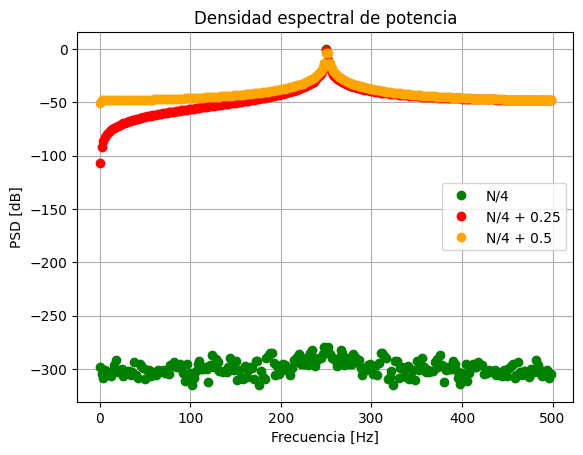

In [3]:
# GRÁFICO FINAL

plt.figure()

plt.plot(frec, PSD1_uni_db, 'o', color="green", label="N/4")
plt.plot(frec, PSD2_uni_db, 'o', color="red", label="N/4 + 0.25")
plt.plot(frec, PSD3_uni_db, 'o', color="orange", label="N/4 + 0.5")

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Densidad espectral de potencia")
plt.grid()
plt.legend()

plt.show()

En el gráfico se observa el efecto de desparramo espectral causado por la desintonía entre la frecuencia de la señal y la grilla de la DFT.
Para k₀ = N/4 (verde), la frecuencia cae exactamente sobre un bin, por lo que toda la energía se concentra en una sola componente y los valores del resto del espectro son despreciables.
Para k₀ = N/4 + 0.25 y k₀ = N/4 + 0.5 (rojo y naranja), la frecuencia no coincide con ningún bin, y la energía se distribuye entre múltiples frecuencias vecinas generando el desparramo. El caso N/4 + 0.5 es el de mayor desintonía posible (exactamente a mitad de camino entre dos bins), por lo que presenta el desparramo más pronunciado.

In [4]:
#%% b) Verificación de potencia usando Parseval

P_s1_tiempo = np.mean(s1**2)
P_s2_tiempo = np.mean(s2**2)
P_s3_tiempo = np.mean(s3**2)

P_s1_freq = np.sum(PSD1_uni)
P_s2_freq = np.sum(PSD2_uni)
P_s3_freq = np.sum(PSD3_uni)

print("Potencia s1 en tiempo:", P_s1_tiempo)
print("Potencia s1 por PSD:", P_s1_freq)

print("Potencia s2 en tiempo:", P_s2_tiempo)
print("Potencia s2 por PSD:", P_s2_freq)

print("Potencia s3 en tiempo:", P_s3_tiempo)
print("Potencia s3 por PSD:", P_s3_freq)

Potencia s1 en tiempo: 1.0000000000000002
Potencia s1 por PSD: 1.0000000000000002
Potencia s2 en tiempo: 0.9980000000000008
Potencia s2 por PSD: 0.9979919748078969
Potencia s3 en tiempo: 1.0000000000000009
Potencia s3 por PSD: 0.9999918988340574


A partir de los valores obtenidos se verifica que la potencia calculada en el dominio temporal coincide con la obtenida a partir de la PSD, confirmando la identidad de Parseval.
En los tres casos la potencia resulta aproximadamente 1, lo cual es consistente con la normalización aplicada (vmax = √2 en una senoidal da varianza unitaria). Las pequeñas diferencias observadas se deben al uso de una cantidad finita de muestras y a la construcción de la PSD unilateral.

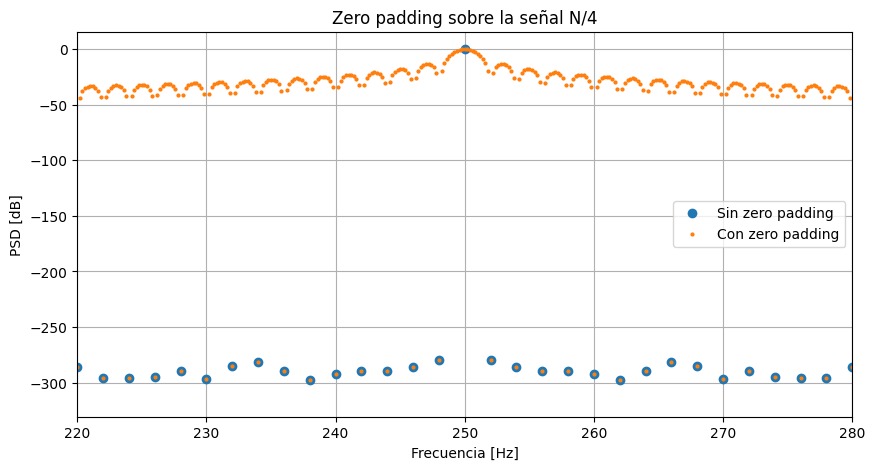

In [6]:
#%% c) Zero padding usando concatenate

# Nuevo tamaño
Npad = int(N+9*N)

# Ejes de frecuencia hechos a mano
df = fs/N
frec = np.arange(0, fs/2, df)

df_zp = fs/Npad
frec_zp = np.arange(0, fs/2, df_zp)


#Zero padding para s1: N/4

ceros = np.zeros(Npad - N)
s1_pad = np.concatenate((s1, ceros))

S1 = np.fft.fft(s1) / N
S1_zp = np.fft.fft(s1_pad) / N

PSD1 = np.abs(S1)**2
PSD1_zp = np.abs(S1_zp)**2

PSD1_uni = PSD1[:N//2].copy()
PSD1_uni[1:] = 2 * PSD1_uni[1:]

PSD1_zp_uni = PSD1_zp[:Npad//2].copy()
PSD1_zp_uni[1:] = 2 * PSD1_zp_uni[1:]

PSD1_uni_db = 10*np.log10(PSD1_uni)
PSD1_zp_uni_db = 10*np.log10(PSD1_zp_uni)

plt.figure(figsize=(10,5))
plt.plot(frec, PSD1_uni_db, 'o', label="Sin zero padding")
plt.plot(frec_zp, PSD1_zp_uni_db, 'o', markersize=2, label="Con zero padding")

plt.xlim(220, 280)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Zero padding sobre la señal N/4")
plt.legend()
plt.grid(True)
plt.show()


Para la señal k₀ = N/4 la frecuencia cae exactamente sobre un bin de la DFT, por lo que sin zero padding la energía aparece concentrada en una única componente espectral.
Al agregar los ceros al final de la señal, la DFT se calcula sobre más puntos, lo que reduce el espaciado frecuencial y hace que el espectro se vea de forma más continua y detallada. Esto no implica una mejora en la resolución espectral real. La señal sigue teniendo la misma cantidad de muestras útiles, por lo que el zero padding únicamente interpola el espectro existente, permitiendo visualizar con mayor claridad la forma de la respuesta espectral.

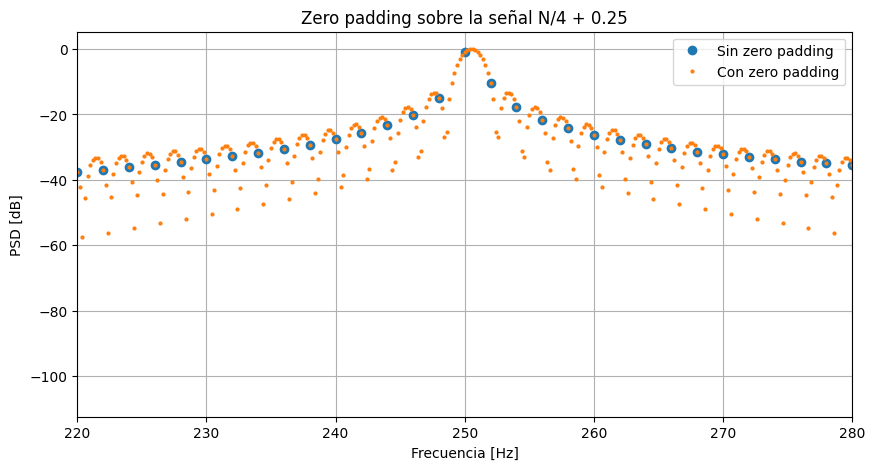

In [7]:
# Zero padding para s2: N/4 + 0.25

ceros = np.zeros(Npad - N)
s2_pad = np.concatenate((s2, ceros))

S2 = np.fft.fft(s2) / N
S2_zp = np.fft.fft(s2_pad) / N

PSD2 = np.abs(S2)**2
PSD2_zp = np.abs(S2_zp)**2

PSD2_uni = PSD2[:N//2].copy()
PSD2_uni[1:] = 2 * PSD2_uni[1:]

PSD2_zp_uni = PSD2_zp[:Npad//2].copy()
PSD2_zp_uni[1:] = 2 * PSD2_zp_uni[1:]

PSD2_uni_db = 10*np.log10(PSD2_uni)
PSD2_zp_uni_db = 10*np.log10(PSD2_zp_uni)

plt.figure(figsize=(10,5))
plt.plot(frec, PSD2_uni_db, 'o', label="Sin zero padding")
plt.plot(frec_zp, PSD2_zp_uni_db, 'o', markersize=2, label="Con zero padding")

plt.xlim(220, 280)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Zero padding sobre la señal N/4 + 0.25")
plt.legend()
plt.grid(True)
plt.show()


Para la señal k0 = N/4 + 0.25 se observa el efecto de desparramo espectral debido a que la frecuencia no coincide exactamente con un bin de la DFT. Por este motivo, la energía de la señal no queda concentrada en un único punto del espectro, sino que se reparte entre varios bins cercanos.

Al aplicar zero padding se obtiene una mayor cantidad de puntos en el espectro, haciendo que la gráfica se vea más continua y permitiendo observar mejor la forma del pico principal y de los lóbulos laterales.

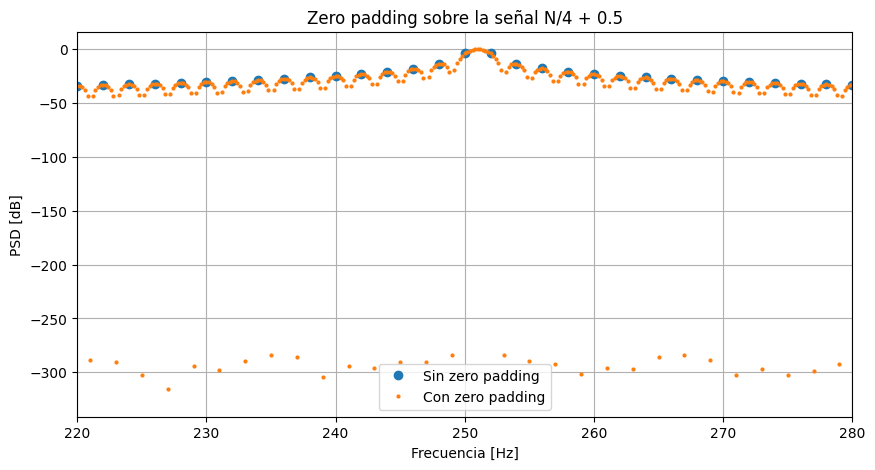

In [8]:
# Zero padding para s3: N/4 + 0.5

ceros = np.zeros(Npad - N)
s3_pad = np.concatenate((s3, ceros))

S3 = np.fft.fft(s3) / N
S3_zp = np.fft.fft(s3_pad) / N

PSD3 = np.abs(S3)**2
PSD3_zp = np.abs(S3_zp)**2

PSD3_uni = PSD3[:N//2].copy()
PSD3_uni[1:] = 2 * PSD3_uni[1:]

PSD3_zp_uni = PSD3_zp[:Npad//2].copy()
PSD3_zp_uni[1:] = 2 * PSD3_zp_uni[1:]

PSD3_uni_db = 10*np.log10(PSD3_uni)
PSD3_zp_uni_db = 10*np.log10(PSD3_zp_uni)

plt.figure(figsize=(10,5))
plt.plot(frec, PSD3_uni_db, 'o', label="Sin zero padding")
plt.plot(frec_zp, PSD3_zp_uni_db, 'o', markersize=2, label="Con zero padding")

plt.xlim(220, 280)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB]")
plt.title("Zero padding sobre la señal N/4 + 0.5")
plt.legend()
plt.grid(True)
plt.show()



Para la señal k0 = N/4 + 0.5 el desparramo espectral se observa de manera más simétrica, ya que la frecuencia está ubicada exactamente entre dos bins de la DFT. Por eso, la energía se reparte de forma similar entre las componentes vecinas.


## Conclusión 
Se pudo observarse cómo pequeñas diferencias en la frecuencia de una señal senoidal generan cambios importantes en la DFT cuando la frecuencia no coincide exactamente con los bins de la grilla espectral. Este efecto produce el desparramo espectral, haciendo que la energía de la señal se desparrame entre varias componentes vecinas.
Además, se verificó mediante la identidad de Parseval que la potencia calculada en el dominio temporal coincide aproximadamente con la obtenida a partir de la PSD.
Finalmente, al aplicar zero padding se obtuvo una representación espectral más detallada y continua. Sin embargo, se observó que esta técnica no mejora la resolución espectral real ni agrega información nueva, ya que la señal original sigue teniendo la misma cantidad de muestras útiles.